# 05 — Backtesting and Economic Sensitivity Analysis

**Author:** Leo Yao 
**Project:** Math 586 — Loan Approval Optimization  

This notebook/script assumes the following files are in the same folder:
- loans_with_decisions.csv
- sensitivity_results.csv
- strategy_comparison.csv

Main outputs:
- refreshed strategy comparison table/plot
- monthly 2017 backtest tables/plots
- purpose concentration diagnostics
- LGD and economic-parameter sensitivity tables/plots

Note: 
The economic sensitivity section is a fixed-decision stress test. It revalues the already-selected portfolios under alternative LGD/cost assumptions. It does NOT re-solve the BIP for every economic parameter combination.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
# Paths
DATA_DIR = Path(".")
OUTPUT_DIR = Path("05_backtesting_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

LOANS_PATH = DATA_DIR / "loans_with_decisions.csv"
SENS_PATH = DATA_DIR / "sensitivity_results.csv"
STRATEGY_PATH = DATA_DIR / "strategy_comparison.csv"

In [3]:
# Base economic assumptions
BASE_LGD = 0.9013
BASE_FUNDING_COST = 0.035
BASE_SERVICING_COST = 0.010
BASE_ORIGINATION_COST = 200.0

# Set to True when running interactively in Jupyter and you want plots displayed inline.
SHOW_PLOTS = False


def save_and_optionally_show(fig, path: Path) -> None:
    fig.savefig(path, dpi=200, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)


# Strategy labels and decision columns.
STRATEGIES = {
    "Approve All": "approve_all",
    "PD Threshold (<0.30)": "approve_threshold",
    "BIP Optimal": "approve_bip",
}

In [4]:
# Load data
loans = pd.read_csv(LOANS_PATH)
sens = pd.read_csv(SENS_PATH)
strategy_original = pd.read_csv(STRATEGY_PATH)

print("Loaded files:")
print(f"  loans_with_decisions.csv: {loans.shape}")
print(f"  sensitivity_results.csv: {sens.shape}")
print(f"  strategy_comparison.csv: {strategy_original.shape}")

print("\nLoan columns:")
print(list(loans.columns))

Loaded files:
  loans_with_decisions.csv: (169321, 34)
  sensitivity_results.csv: (35, 14)
  strategy_comparison.csv: (3, 10)

Loan columns:
['id', 'issue_year', 'loan_status', 'target_default', 'pred_default_prob', 'loan_amnt', 'term', 'purpose', 'addr_state', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 'application_type', 'int_rate', 'installment', 'grade', 'sub_grade', 'issue_d', 'term_months', 'pd_calibrated', 'monthly_payment', 'total_interest', 'avg_balance', 'term_years', 'funding_cost', 'servicing_cost', 'net_income_good', 'ead', 'expected_loss', 'pi', 'approve_bip', 'approve_all', 'approve_threshold']


In [5]:
# Basic data checks
required_cols = [
    "target_default",
    "loan_amnt",
    "purpose",
    "issue_d",
    "pd_calibrated",
    "total_interest",
    "avg_balance",
    "term_years",
    "ead",
    "approve_all",
    "approve_threshold",
    "approve_bip",
]
missing = [c for c in required_cols if c not in loans.columns]
if missing:
    raise ValueError(f"Missing required columns in loans_with_decisions.csv: {missing}")

In [6]:
# Parse issue month for vintage/monthly backtesting.
# LendingClub issue_d is typically like "Jan-2017".
loans["issue_month"] = pd.to_datetime(loans["issue_d"], format="%b-%Y", errors="coerce")
if loans["issue_month"].isna().any():
    # Fallback parser if the format differs.
    loans["issue_month"] = pd.to_datetime(loans["issue_d"], errors="coerce")

if loans["issue_month"].isna().any():
    bad_examples = loans.loc[loans["issue_month"].isna(), "issue_d"].head(10).tolist()
    raise ValueError(f"Could not parse some issue_d values. Examples: {bad_examples}")

In [7]:
# Force decision columns to 0/1 integers.
for col in STRATEGIES.values():
    loans[col] = loans[col].fillna(0).astype(int)

print("Issue-month coverage:")
print(loans["issue_month"].dt.strftime("%Y-%m").value_counts().sort_index().to_string())

Issue-month coverage:
issue_month
2017-01    16395
2017-02    13468
2017-03    17011
2017-04    13104
2017-05    16153
2017-06    15235
2017-07    14959
2017-08    15489
2017-09    13406
2017-10    11926
2017-11    12112
2017-12    10063


In [8]:
# Cash-flow and evaluation functions
def add_cashflow_columns(
    df: pd.DataFrame,
    lgd: float = BASE_LGD,
    funding_cost: float = BASE_FUNDING_COST,
    servicing_cost: float = BASE_SERVICING_COST,
    origination_cost: float = BASE_ORIGINATION_COST,
) -> pd.DataFrame:
    """
    Revalue expected and realized loan-level cash flows under a given economic scenario.

    Expected profit:
        pi = (1 - PD_cal) * net_income_good
             - PD_cal * LGD * EAD
             - origination_cost

    Realized profit:
        if no default: net_income_good - origination_cost
        if default:   - LGD * EAD - origination_cost

    Notes:
    - This uses the existing loan decisions and revalues them.
    - It does not re-optimize the portfolio under the new assumptions.
    """
    out = df.copy()

    out["funding_cost_scn"] = funding_cost * out["avg_balance"] * out["term_years"]
    out["servicing_cost_scn"] = servicing_cost * out["avg_balance"] * out["term_years"]
    out["net_income_good_scn"] = (
        out["total_interest"] - out["funding_cost_scn"] - out["servicing_cost_scn"]
    )
    out["expected_loss_scn"] = out["pd_calibrated"] * lgd * out["ead"]
    out["pi_scn"] = (
        (1.0 - out["pd_calibrated"]) * out["net_income_good_scn"]
        - out["expected_loss_scn"]
        - origination_cost
    )
    out["realized_profit_scn"] = np.where(
        out["target_default"].eq(0),
        out["net_income_good_scn"] - origination_cost,
        -lgd * out["ead"] - origination_cost,
    )
    return out


def evaluate_strategy(
    df: pd.DataFrame,
    approve_col: str,
    strategy_name: str,
) -> dict:
    """Compute core metrics for one strategy on one DataFrame slice."""
    sub = df[df[approve_col].eq(1)]
    n_total = len(df)

    if len(sub) == 0:
        return {
            "strategy": strategy_name,
            "n_approved": 0,
            "approval_rate": 0.0,
            "total_volume": 0.0,
            "weighted_pd": np.nan,
            "actual_default_rate": np.nan,
            "expected_profit": 0.0,
            "realized_profit": 0.0,
            "roi_expected_pct": np.nan,
            "roi_realized_pct": np.nan,
        }

    total_volume = sub["loan_amnt"].sum()
    expected_profit = sub["pi_scn"].sum()
    realized_profit = sub["realized_profit_scn"].sum()

    return {
        "strategy": strategy_name,
        "n_approved": int(len(sub)),
        "approval_rate": len(sub) / n_total * 100,
        "total_volume": total_volume,
        "weighted_pd": np.average(sub["pd_calibrated"], weights=sub["loan_amnt"]),
        "actual_default_rate": sub["target_default"].mean() * 100,
        "expected_profit": expected_profit,
        "realized_profit": realized_profit,
        "roi_expected_pct": expected_profit / total_volume * 100,
        "roi_realized_pct": realized_profit / total_volume * 100,
    }


def evaluate_all_strategies(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for strategy_name, approve_col in STRATEGIES.items():
        rows.append(evaluate_strategy(df, approve_col, strategy_name))
    return pd.DataFrame(rows)


def dollars_m(x: float) -> str:
    return f"${x/1e6:,.1f}M"


def dollars_b(x: float) -> str:
    return f"${x/1e9:,.2f}B"

In [9]:
# Revalue the base case and verify against strategy_comparison.csv.
loans_base = add_cashflow_columns(loans)
strategy_recomputed = evaluate_all_strategies(loans_base)

strategy_recomputed.to_csv(
    TABLE_DIR / "strategy_comparison_recomputed.csv", index=False
)

print("Recomputed strategy comparison under base economic assumptions:")
display_cols = [
    "strategy",
    "n_approved",
    "approval_rate",
    "total_volume",
    "weighted_pd",
    "actual_default_rate",
    "realized_profit",
    "roi_realized_pct",
]
print(strategy_recomputed[display_cols].round(4).to_string(index=False))

print("\nOriginal strategy_comparison.csv:")
print(strategy_original.round(4).to_string(index=False))

Recomputed strategy comparison under base economic assumptions:
            strategy  n_approved  approval_rate  total_volume  weighted_pd  actual_default_rate  realized_profit  roi_realized_pct
         Approve All      169321       100.0000  2421502475.0       0.2536              23.1330     6.440534e+07            2.6597
PD Threshold (<0.30)      121036        71.4832  1535167825.0       0.1721              16.9305     3.131344e+07            2.0397
         BIP Optimal       65019        38.3998   935093675.0       0.2000              20.2510     6.243966e+07            6.6774

Original strategy_comparison.csv:
               strategy  n_approved  approval_rate  total_volume  avg_pd  actual_default_rate  expected_profit  realized_profit  roi_expected_pct  roi_realized_pct
         A. Approve All      169321       100.0000  2421502475.0  0.2536              23.1330     7.296138e+07     6.440534e+07            3.0131            2.6597
B. PD Threshold (<0.30)      121036        71.483

In [10]:
# Plot 1: Core three-strategy comparison
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
labels = strategy_recomputed["strategy"].tolist()
x = np.arange(len(labels))

metric_specs = [
    ("approval_rate", "Approval rate (%)", "Approval Rate"),
    ("actual_default_rate", "Realized default rate (%)", "Backtested Default Rate"),
    ("realized_profit", "Realized profit ($M)", "Backtested Realized Profit"),
    ("roi_realized_pct", "Realized ROI (%)", "Backtested ROI"),
]

for ax, (col, ylabel, title) in zip(axes.ravel(), metric_specs):
    values = strategy_recomputed[col].copy()
    plot_values = values / 1e6 if col == "realized_profit" else values

    ax.bar(x, plot_values)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

    for i, v in enumerate(plot_values):
        if col == "realized_profit":
            txt = f"${v:.1f}M"
        else:
            txt = f"{v:.2f}%"
        ax.text(i, v + (0.03 * max(plot_values)), txt, ha="center", fontsize=9)

plt.tight_layout()
save_and_optionally_show(fig, FIG_DIR / "strategy_core_metrics.png")

In [11]:
# Monthly 2017 backtesting
monthly_rows = []

for issue_month, g in loans_base.groupby("issue_month", sort=True):
    one_month = evaluate_all_strategies(g)
    one_month["issue_month"] = issue_month
    one_month["n_loans_in_month"] = len(g)
    monthly_rows.append(one_month)

monthly_backtest = pd.concat(monthly_rows, ignore_index=True)
monthly_backtest = monthly_backtest.sort_values(["strategy", "issue_month"])

# Cumulative realized profit by strategy over issue months
monthly_backtest["cumulative_realized_profit"] = monthly_backtest.groupby("strategy")[
    "realized_profit"
].cumsum()

monthly_backtest.to_csv(TABLE_DIR / "monthly_backtest_by_strategy.csv", index=False)

print("Monthly backtest preview:")
print(
    monthly_backtest[
        [
            "issue_month",
            "strategy",
            "n_approved",
            "approval_rate",
            "actual_default_rate",
            "realized_profit",
            "roi_realized_pct",
        ]
    ]
    .round(3)
    .head(15)
    .to_string(index=False)
)

Monthly backtest preview:
issue_month    strategy  n_approved  approval_rate  actual_default_rate  realized_profit  roi_realized_pct
 2017-01-01 Approve All       16395        100.000               22.690      7850286.963             3.302
 2017-02-01 Approve All       13468        100.000               23.218      5555053.613             2.815
 2017-03-01 Approve All       17011        100.000               22.950      5487663.827             2.234
 2017-04-01 Approve All       13104        100.000               23.802      3965015.762             2.106
 2017-05-01 Approve All       16153        100.000               23.946      4472053.047             1.967
 2017-06-01 Approve All       15235        100.000               23.656      5725929.489             2.677
 2017-07-01 Approve All       14959        100.000               24.072      5310989.821             2.565
 2017-08-01 Approve All       15489        100.000               22.900      6071198.769             2.862
 2017-09-01

In [12]:
# Plot 2: Montly realized ROI
fig, ax = plt.subplots(figsize=(11, 6))
for strategy_name in STRATEGIES:
    sub = monthly_backtest[monthly_backtest["strategy"].eq(strategy_name)]
    ax.plot(
        sub["issue_month"], sub["roi_realized_pct"], marker="o", label=strategy_name
    )

ax.set_title("Monthly Backtest: Realized ROI by Issue Month")
ax.set_xlabel("Issue month")
ax.set_ylabel("Realized ROI (%)")
ax.grid(alpha=0.25)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
save_and_optionally_show(fig, FIG_DIR / "monthly_realized_roi.png")

# Plot 3: Cumulative realized profit
fig, ax = plt.subplots(figsize=(11, 6))
for strategy_name in STRATEGIES:
    sub = monthly_backtest[monthly_backtest["strategy"].eq(strategy_name)]
    ax.plot(
        sub["issue_month"],
        sub["cumulative_realized_profit"] / 1e6,
        marker="o",
        label=strategy_name,
    )

ax.set_title("Monthly Backtest: Cumulative Realized Profit")
ax.set_xlabel("Issue month")
ax.set_ylabel("Cumulative realized profit ($M)")
ax.grid(alpha=0.25)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
save_and_optionally_show(fig, FIG_DIR / "monthly_cumulative_profit.png")

# Plot 4: Monthly realized default rate
fig, ax = plt.subplots(figsize=(11, 6))
for strategy_name in STRATEGIES:
    sub = monthly_backtest[monthly_backtest["strategy"].eq(strategy_name)]
    ax.plot(
        sub["issue_month"], sub["actual_default_rate"], marker="o", label=strategy_name
    )

ax.set_title("Monthly Backtest: Realized Default Rate by Issue Month")
ax.set_xlabel("Issue month")
ax.set_ylabel("Realized default rate (%)")
ax.grid(alpha=0.25)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
save_and_optionally_show(fig, FIG_DIR / "monthly_default_rate.png")

In [13]:
# Backtest stability summary
stability_rows = []
for strategy_name in STRATEGIES:
    sub = monthly_backtest[monthly_backtest["strategy"].eq(strategy_name)].copy()
    stability_rows.append(
        {
            "strategy": strategy_name,
            "mean_monthly_roi_pct": sub["roi_realized_pct"].mean(),
            "std_monthly_roi_pct": sub["roi_realized_pct"].std(),
            "min_monthly_roi_pct": sub["roi_realized_pct"].min(),
            "max_monthly_roi_pct": sub["roi_realized_pct"].max(),
            "positive_profit_months": int((sub["realized_profit"] > 0).sum()),
            "total_months": int(len(sub)),
            "mean_monthly_default_rate_pct": sub["actual_default_rate"].mean(),
            "std_monthly_default_rate_pct": sub["actual_default_rate"].std(),
        }
    )

stability_summary = pd.DataFrame(stability_rows)
stability_summary.to_csv(TABLE_DIR / "backtest_stability_summary.csv", index=False)

print("Backtest stability summary:")
print(stability_summary.round(3).to_string(index=False))

Backtest stability summary:
            strategy  mean_monthly_roi_pct  std_monthly_roi_pct  min_monthly_roi_pct  max_monthly_roi_pct  positive_profit_months  total_months  mean_monthly_default_rate_pct  std_monthly_default_rate_pct
         Approve All                 2.671                0.391                1.967                3.302                      12            12                         23.057                         1.165
PD Threshold (<0.30)                 2.032                0.218                1.695                2.386                      12            12                         16.830                         0.954
         BIP Optimal                 6.658                0.673                5.781                7.830                      12            12                         20.202                         1.162


In [14]:
# Purpose concentration diagnostics
purpose_rows = []

for strategy_name, approve_col in STRATEGIES.items():
    sub = loans_base[loans_base[approve_col].eq(1)].copy()
    total_volume = sub["loan_amnt"].sum()

    by_purpose = sub.groupby("purpose", as_index=False).agg(
        n_approved=("id", "count"),
        total_volume=("loan_amnt", "sum"),
        realized_default_rate=("target_default", "mean"),
        realized_profit=("realized_profit_scn", "sum"),
    )
    by_purpose["strategy"] = strategy_name
    by_purpose["volume_share_pct"] = by_purpose["total_volume"] / total_volume * 100
    by_purpose["realized_default_rate"] *= 100
    by_purpose["roi_realized_pct"] = (
        by_purpose["realized_profit"] / by_purpose["total_volume"] * 100
    )
    purpose_rows.append(by_purpose)

purpose_composition = pd.concat(purpose_rows, ignore_index=True)
purpose_composition = purpose_composition.sort_values(
    ["strategy", "volume_share_pct"], ascending=[True, False]
)
purpose_composition.to_csv(
    TABLE_DIR / "purpose_composition_by_strategy.csv", index=False
)

max_purpose = purpose_composition.groupby("strategy", as_index=False).agg(
    max_purpose_share_pct=("volume_share_pct", "max"),
    largest_purpose=(
        "purpose",
        lambda x: purpose_composition.loc[x.index, :]
        .sort_values("volume_share_pct", ascending=False)["purpose"]
        .iloc[0],
    ),
)
max_purpose.to_csv(TABLE_DIR / "purpose_concentration_summary.csv", index=False)

print("Purpose concentration summary:")
print(max_purpose.round(3).to_string(index=False))

Purpose concentration summary:
            strategy  max_purpose_share_pct    largest_purpose
         Approve All                 60.593 debt_consolidation
         BIP Optimal                 30.000 debt_consolidation
PD Threshold (<0.30)                 57.678 debt_consolidation


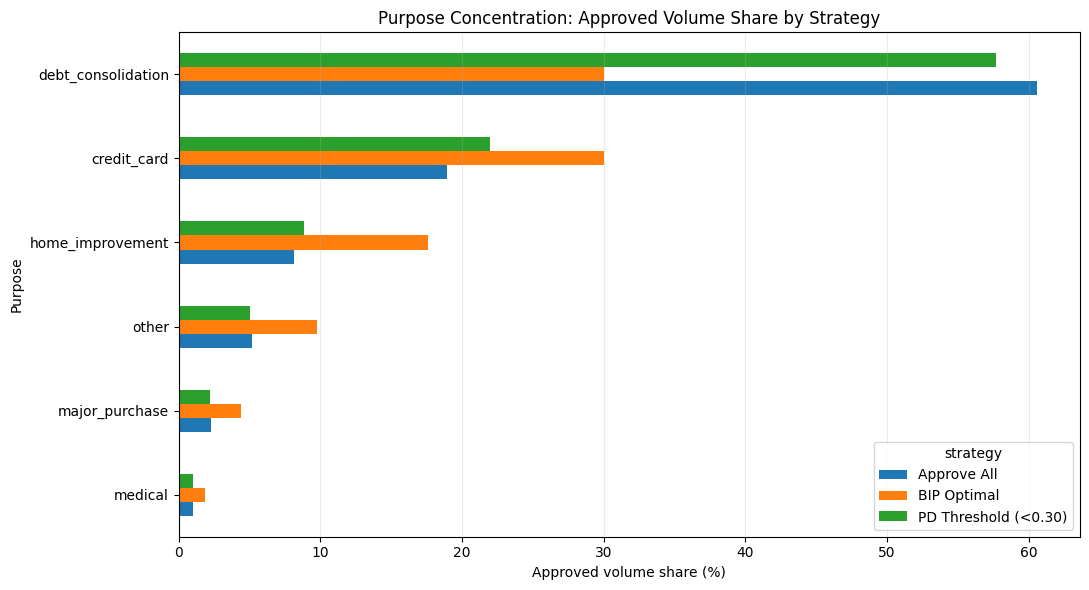

In [15]:
# Plot 5: Top purposes by volume share
top_purposes = (
    purpose_composition.groupby("purpose")["total_volume"]
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

plot_df = purpose_composition[purpose_composition["purpose"].isin(top_purposes)].copy()
pivot = plot_df.pivot(
    index="purpose", columns="strategy", values="volume_share_pct"
).fillna(0)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=True).index]

ax = pivot.plot(kind="barh", figsize=(11, 6))
ax.set_title("Purpose Concentration: Approved Volume Share by Strategy")
ax.set_xlabel("Approved volume share (%)")
ax.set_ylabel("Purpose")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
save_and_optionally_show(fig, FIG_DIR / "purpose_concentration_by_strategy.png")

In [16]:
# Policy sensitivity from existing sensitivity_results.csv
sens2 = sens.copy()
if "roi_realized" in sens2.columns and sens2["roi_realized"].max() < 1:
    # Defensive conversion if stored as decimal rather than percent.
    sens2["roi_realized"] *= 100
if (
    "realized_default_rate" in sens2.columns
    and sens2["realized_default_rate"].max() < 1
):
    sens2["realized_default_rate"] *= 100

sens2["budget_label"] = sens2["budget"].apply(lambda v: f"${v/1e9:.1f}B")
sens2.to_csv(TABLE_DIR / "policy_sensitivity_clean.csv", index=False)

# Identify policy-grid sweet spots.
best_roi = sens2.loc[sens2["roi_realized"].idxmax()]
best_profit = sens2.loc[sens2["realized_profit"].idxmax()]
low_risk_pool = sens2[sens2["realized_default_rate"] <= 18.0]
best_low_risk = (
    low_risk_pool.loc[low_risk_pool["realized_profit"].idxmax()]
    if len(low_risk_pool) > 0
    else None
)

sweet_spots = pd.DataFrame(
    [
        {
            "sweet_spot": "Highest realized ROI",
            "budget": best_roi["budget"],
            "pd_cap": best_roi["pd_cap"],
            "n_approved": best_roi["n_approved"],
            "approval_rate": best_roi["approval_rate"],
            "realized_default_rate": best_roi["realized_default_rate"],
            "realized_profit": best_roi["realized_profit"],
            "roi_realized": best_roi["roi_realized"],
        },
        {
            "sweet_spot": "Highest total realized profit",
            "budget": best_profit["budget"],
            "pd_cap": best_profit["pd_cap"],
            "n_approved": best_profit["n_approved"],
            "approval_rate": best_profit["approval_rate"],
            "realized_default_rate": best_profit["realized_default_rate"],
            "realized_profit": best_profit["realized_profit"],
            "roi_realized": best_profit["roi_realized"],
        },
    ]
)

if best_low_risk is not None:
    sweet_spots = pd.concat(
        [
            sweet_spots,
            pd.DataFrame(
                [
                    {
                        "sweet_spot": "Best profit subject to default rate <= 18%",
                        "budget": best_low_risk["budget"],
                        "pd_cap": best_low_risk["pd_cap"],
                        "n_approved": best_low_risk["n_approved"],
                        "approval_rate": best_low_risk["approval_rate"],
                        "realized_default_rate": best_low_risk["realized_default_rate"],
                        "realized_profit": best_low_risk["realized_profit"],
                        "roi_realized": best_low_risk["roi_realized"],
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

sweet_spots.to_csv(TABLE_DIR / "policy_sweet_spots.csv", index=False)

print("Policy-grid sweet spots:")
print(sweet_spots.round(3).to_string(index=False))

Policy-grid sweet spots:
                                sweet_spot       budget  pd_cap  n_approved  approval_rate  realized_default_rate  realized_profit  roi_realized
                      Highest realized ROI  500000000.0    0.28       29273         17.288                 28.326     57806648.479        11.562
             Highest total realized profit 1000000000.0    0.25       64368         38.015                 24.518     70288842.728         7.029
Best profit subject to default rate <= 18% 1000000000.0    0.15       49476         29.220                 15.747     44196442.157         6.520


In [17]:
# Plot 6: Efficient frontier from existing sensitivity results
fig, ax = plt.subplots(figsize=(10, 6))
for budget, sub in sens2.groupby("budget"):
    sub = sub.sort_values("pd_cap")
    ax.plot(
        sub["realized_default_rate"],
        sub["roi_realized"],
        marker="o",
        label=f"${budget/1e9:.1f}B",
    )

# Add benchmark strategies from recomputed strategy comparison
for _, row in strategy_recomputed.iterrows():
    ax.scatter(row["actual_default_rate"], row["roi_realized_pct"], marker="x", s=90)
    ax.text(
        row["actual_default_rate"] + 0.15,
        row["roi_realized_pct"] + 0.05,
        row["strategy"],
        fontsize=9,
    )

ax.set_title("Policy Sensitivity: Efficient Frontier")
ax.set_xlabel("Realized default rate (%)")
ax.set_ylabel("Realized ROI (%)")
ax.grid(alpha=0.25)
ax.legend(title="Budget")
plt.tight_layout()
save_and_optionally_show(fig, FIG_DIR / "policy_efficient_frontier.png")

In [18]:
# Plot 7: Profit and approval rate by PD cap and budget
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for budget, sub in sens2.groupby("budget"):
    sub = sub.sort_values("pd_cap")
    label = f"${budget/1e9:.1f}B"
    axes[0].plot(sub["pd_cap"], sub["realized_profit"] / 1e6, marker="o", label=label)
    axes[1].plot(sub["pd_cap"], sub["approval_rate"], marker="o", label=label)

axes[0].set_title("Realized Profit vs Portfolio PD Cap")
axes[0].set_xlabel("Portfolio PD cap")
axes[0].set_ylabel("Realized profit ($M)")
axes[0].grid(alpha=0.25)
axes[0].legend(title="Budget")

axes[1].set_title("Approval Rate vs Portfolio PD Cap")
axes[1].set_xlabel("Portfolio PD cap")
axes[1].set_ylabel("Approval rate (%)")
axes[1].grid(alpha=0.25)
axes[1].legend(title="Budget")

plt.tight_layout()
save_and_optionally_show(fig, FIG_DIR / "policy_profit_approval_vs_pd_cap.png")

In [19]:
# Economic parameter sensitivity: fixed-decision stress tests
# LGD grid:
# - 0.65: teammate's original assumption
# - 0.75: useful Basel-style high-loss benchmark, though retail exposures require own LGD estimates
# - 0.80-1.00: neighborhood around the current empirical estimate 0.9013
LGD_GRID = [0.65, 0.75, 0.80, 0.85, 0.90, BASE_LGD, 0.95, 1.00]
FUNDING_GRID = [0.020, BASE_FUNDING_COST, 0.050, 0.070]
SERVICING_GRID = [0.005, BASE_SERVICING_COST, 0.015, 0.020]
ORIGINATION_GRID = [100.0, BASE_ORIGINATION_COST, 300.0, 500.0]

sensitivity_rows = []

# One-way LGD sensitivity
for lgd in LGD_GRID:
    temp = add_cashflow_columns(loans, lgd=lgd)
    metrics = evaluate_all_strategies(temp)
    metrics["scenario_type"] = "LGD"
    metrics["scenario_value"] = lgd
    metrics["lgd"] = lgd
    metrics["funding_cost"] = BASE_FUNDING_COST
    metrics["servicing_cost"] = BASE_SERVICING_COST
    metrics["origination_cost"] = BASE_ORIGINATION_COST
    sensitivity_rows.append(metrics)

# One-way funding cost sensitivity
for fc in FUNDING_GRID:
    temp = add_cashflow_columns(loans, funding_cost=fc)
    metrics = evaluate_all_strategies(temp)
    metrics["scenario_type"] = "Funding cost"
    metrics["scenario_value"] = fc
    metrics["lgd"] = BASE_LGD
    metrics["funding_cost"] = fc
    metrics["servicing_cost"] = BASE_SERVICING_COST
    metrics["origination_cost"] = BASE_ORIGINATION_COST
    sensitivity_rows.append(metrics)

# One-way servicing cost sensitivity
for sc in SERVICING_GRID:
    temp = add_cashflow_columns(loans, servicing_cost=sc)
    metrics = evaluate_all_strategies(temp)
    metrics["scenario_type"] = "Servicing cost"
    metrics["scenario_value"] = sc
    metrics["lgd"] = BASE_LGD
    metrics["funding_cost"] = BASE_FUNDING_COST
    metrics["servicing_cost"] = sc
    metrics["origination_cost"] = BASE_ORIGINATION_COST
    sensitivity_rows.append(metrics)

# One-way origination cost sensitivity
for oc in ORIGINATION_GRID:
    temp = add_cashflow_columns(loans, origination_cost=oc)
    metrics = evaluate_all_strategies(temp)
    metrics["scenario_type"] = "Origination cost"
    metrics["scenario_value"] = oc
    metrics["lgd"] = BASE_LGD
    metrics["funding_cost"] = BASE_FUNDING_COST
    metrics["servicing_cost"] = BASE_SERVICING_COST
    metrics["origination_cost"] = oc
    sensitivity_rows.append(metrics)

economic_sensitivity = pd.concat(sensitivity_rows, ignore_index=True)
economic_sensitivity.to_csv(TABLE_DIR / "economic_sensitivity_one_way.csv", index=False)

print("Economic sensitivity table saved.")
print(
    economic_sensitivity[
        [
            "scenario_type",
            "scenario_value",
            "strategy",
            "realized_profit",
            "roi_realized_pct",
        ]
    ]
    .round(4)
    .head(20)
    .to_string(index=False)
)

Economic sensitivity table saved.
scenario_type  scenario_value             strategy  realized_profit  roi_realized_pct
          LGD          0.6500          Approve All     1.421974e+08            5.8723
          LGD          0.6500 PD Threshold (<0.30)     6.561467e+07            4.2741
          LGD          0.6500          BIP Optimal     8.911747e+07            9.5303
          LGD          0.7500          Approve All     1.112416e+08            4.5939
          LGD          0.7500 PD Threshold (<0.30)     5.196516e+07            3.3850
          LGD          0.7500          BIP Optimal     7.850155e+07            8.3950
          LGD          0.8000          Approve All     9.576362e+07            3.9547
          LGD          0.8000 PD Threshold (<0.30)     4.514040e+07            2.9404
          LGD          0.8000          BIP Optimal     7.319359e+07            7.8274
          LGD          0.8500          Approve All     8.028569e+07            3.3155
          LGD       

In [20]:
# Plot 8: LGD sensitivity across strategies
lgd_sens = economic_sensitivity[economic_sensitivity["scenario_type"].eq("LGD")].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for strategy_name in STRATEGIES:
    sub = lgd_sens[lgd_sens["strategy"].eq(strategy_name)].sort_values("scenario_value")
    axes[0].plot(
        sub["scenario_value"],
        sub["realized_profit"] / 1e6,
        marker="o",
        label=strategy_name,
    )
    axes[1].plot(
        sub["scenario_value"], sub["roi_realized_pct"], marker="o", label=strategy_name
    )

axes[0].axvline(BASE_LGD, linestyle="--", alpha=0.5)
axes[0].set_title("LGD Sensitivity: Realized Profit")
axes[0].set_xlabel("LGD")
axes[0].set_ylabel("Realized profit ($M)")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].axvline(BASE_LGD, linestyle="--", alpha=0.5)
axes[1].set_title("LGD Sensitivity: Realized ROI")
axes[1].set_xlabel("LGD")
axes[1].set_ylabel("Realized ROI (%)")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
save_and_optionally_show(fig, FIG_DIR / "lgd_sensitivity_by_strategy.png")

In [21]:
# Plot 9: Economic one-way sensitivities for BIP Optimal only
bip_sens = economic_sensitivity[
    economic_sensitivity["strategy"].eq("BIP Optimal")
].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, scenario_type in zip(
    axes.ravel(), ["LGD", "Funding cost", "Servicing cost", "Origination cost"]
):
    sub = bip_sens[bip_sens["scenario_type"].eq(scenario_type)].sort_values(
        "scenario_value"
    )
    ax.plot(sub["scenario_value"], sub["roi_realized_pct"], marker="o")
    ax.set_title(f"BIP ROI sensitivity: {scenario_type}")
    ax.set_xlabel(scenario_type)
    ax.set_ylabel("Realized ROI (%)")
    ax.grid(alpha=0.25)

plt.tight_layout()
save_and_optionally_show(fig, FIG_DIR / "bip_economic_one_way_sensitivity.png")

In [22]:
# Two-way stress test: LGD x funding cost for BIP decision
stress_rows = []
for lgd in LGD_GRID:
    for fc in FUNDING_GRID:
        temp = add_cashflow_columns(loans, lgd=lgd, funding_cost=fc)
        row = evaluate_strategy(temp, "approve_bip", "BIP Optimal")
        row["lgd"] = lgd
        row["funding_cost"] = fc
        stress_rows.append(row)

bip_lgd_funding_stress = pd.DataFrame(stress_rows)
bip_lgd_funding_stress.to_csv(TABLE_DIR / "bip_lgd_funding_stress.csv", index=False)

stress_pivot = bip_lgd_funding_stress.pivot(
    index="lgd", columns="funding_cost", values="roi_realized_pct"
)
print("BIP LGD x funding-cost stress test, values are realized ROI (%):")
print(stress_pivot.round(2).to_string())

BIP LGD x funding-cost stress test, values are realized ROI (%):
funding_cost  0.020  0.035  0.050  0.070
lgd                                     
0.6500        11.61   9.53   7.45   4.67
0.7500        10.48   8.40   6.31   3.54
0.8000         9.91   7.83   5.75   2.97
0.8500         9.34   7.26   5.18   2.40
0.9000         8.77   6.69   4.61   1.84
0.9013         8.76   6.68   4.60   1.82
0.9500         8.21   6.12   4.04   1.27
1.0000         7.64   5.56   3.48   0.70


In [23]:
# Plot 10: Heatmap for BIP LGD x funding cost stress test
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(stress_pivot.values, aspect="auto", origin="lower")

ax.set_xticks(np.arange(len(stress_pivot.columns)))
ax.set_xticklabels([f"{c:.1%}" for c in stress_pivot.columns])
ax.set_yticks(np.arange(len(stress_pivot.index)))
ax.set_yticklabels([f"{i:.4g}" for i in stress_pivot.index])

ax.set_xlabel("Annual funding cost")
ax.set_ylabel("LGD")
ax.set_title("BIP Stress Test: Realized ROI (%) under LGD × Funding Cost")

for i in range(stress_pivot.shape[0]):
    for j in range(stress_pivot.shape[1]):
        ax.text(
            j,
            i,
            f"{stress_pivot.values[i, j]:.1f}",
            ha="center",
            va="center",
            fontsize=9,
        )

fig.colorbar(im, ax=ax, label="Realized ROI (%)")
plt.tight_layout()
save_and_optionally_show(fig, FIG_DIR / "bip_lgd_funding_heatmap.png")

In [24]:
# Break-even LGD calculation by strategy.
# Holding funding/servicing/origination at base values:
# realized profit = good_cashflow_sum - LGD * default_ead_sum - origination costs.
# This function solves for LGD where realized profit = 0.
breakeven_rows = []
temp_base_no_lgd = add_cashflow_columns(loans, lgd=0.0)

for strategy_name, approve_col in STRATEGIES.items():
    sub = temp_base_no_lgd[temp_base_no_lgd[approve_col].eq(1)].copy()

    good_part = sub.loc[sub["target_default"].eq(0), "net_income_good_scn"].sum()
    origination_total = BASE_ORIGINATION_COST * len(sub)
    default_ead_sum = sub.loc[sub["target_default"].eq(1), "ead"].sum()

    breakeven_lgd = (
        (good_part - origination_total) / default_ead_sum
        if default_ead_sum > 0
        else np.nan
    )

    # Profit slope: each +0.01 increase in LGD reduces realized profit by 1% of default EAD.
    profit_impact_per_1pct_lgd = -0.01 * default_ead_sum

    breakeven_rows.append(
        {
            "strategy": strategy_name,
            "n_approved": len(sub),
            "default_ead_sum": default_ead_sum,
            "breakeven_lgd": breakeven_lgd,
            "profit_impact_per_1pct_lgd": profit_impact_per_1pct_lgd,
        }
    )

breakeven_lgd = pd.DataFrame(breakeven_rows)
breakeven_lgd.to_csv(TABLE_DIR / "breakeven_lgd_by_strategy.csv", index=False)

print("Break-even LGD by strategy:")
print(breakeven_lgd.round(4).to_string(index=False))

Break-even LGD by strategy:
            strategy  n_approved  default_ead_sum  breakeven_lgd  profit_impact_per_1pct_lgd
         Approve All      169321      309558625.0         1.1094                -3095586.250
PD Threshold (<0.30)      121036      136495150.0         1.1307                -1364951.500
         BIP Optimal       65019      106159212.5         1.4895                -1061592.125


In [25]:
# Generate a compact text summary for easy copy/paste into the report later.
summary_lines = []

base_bip = strategy_recomputed[strategy_recomputed["strategy"].eq("BIP Optimal")].iloc[
    0
]
base_all = strategy_recomputed[strategy_recomputed["strategy"].eq("Approve All")].iloc[
    0
]
base_thresh = strategy_recomputed[
    strategy_recomputed["strategy"].eq("PD Threshold (<0.30)")
].iloc[0]

summary_lines.append("BACKTESTING SUMMARY")
summary_lines.append("-------------------")
summary_lines.append(
    f"In the 2017 held-out vintage, BIP approved {base_bip['n_approved']:,} loans "
    f"({base_bip['approval_rate']:.1f}% of the pool), generated "
    f"{dollars_m(base_bip['realized_profit'])} in realized profit, and achieved "
    f"{base_bip['roi_realized_pct']:.2f}% realized ROI."
)
summary_lines.append(
    f"Approve All generated {dollars_m(base_all['realized_profit'])} but required "
    f"{dollars_b(base_all['total_volume'])} of capital, producing only "
    f"{base_all['roi_realized_pct']:.2f}% ROI."
)
summary_lines.append(
    f"The PD-threshold rule had the lowest realized default rate "
    f"({base_thresh['actual_default_rate']:.2f}%) but also the weakest realized profit "
    f"({dollars_m(base_thresh['realized_profit'])}), showing that risk minimization alone "
    f"does not maximize economic value."
)

st_bip = stability_summary[stability_summary["strategy"].eq("BIP Optimal")].iloc[0]
summary_lines.append(
    f"Across monthly 2017 issue cohorts, BIP had positive realized profit in "
    f"{int(st_bip['positive_profit_months'])}/{int(st_bip['total_months'])} months, "
    f"with mean monthly ROI {st_bip['mean_monthly_roi_pct']:.2f}%."
)

summary_lines.append("")
summary_lines.append("ECONOMIC SENSITIVITY SUMMARY")
summary_lines.append("----------------------------")

bip_lgd_table = lgd_sens[lgd_sens["strategy"].eq("BIP Optimal")].sort_values(
    "scenario_value"
)
lgd_065 = bip_lgd_table.loc[np.isclose(bip_lgd_table["scenario_value"], 0.65)].iloc[0]
lgd_base = bip_lgd_table.loc[
    np.isclose(bip_lgd_table["scenario_value"], BASE_LGD)
].iloc[0]
lgd_100 = bip_lgd_table.loc[np.isclose(bip_lgd_table["scenario_value"], 1.00)].iloc[0]

summary_lines.append(
    f"When LGD is stressed from 0.65 to {BASE_LGD:.4f} to 1.00, BIP realized ROI moves from "
    f"{lgd_065['roi_realized_pct']:.2f}% to {lgd_base['roi_realized_pct']:.2f}% to "
    f"{lgd_100['roi_realized_pct']:.2f}%."
)

bip_be = breakeven_lgd[breakeven_lgd["strategy"].eq("BIP Optimal")].iloc[0]
summary_lines.append(
    f"The BIP portfolio's break-even LGD is approximately {bip_be['breakeven_lgd']:.3f}; "
    f"each 1 percentage point increase in LGD changes BIP realized profit by about "
    f"{dollars_m(bip_be['profit_impact_per_1pct_lgd'])}."
)

max_bip_purpose = max_purpose[max_purpose["strategy"].eq("BIP Optimal")].iloc[0]
summary_lines.append(
    f"The BIP portfolio's largest purpose exposure is {max_bip_purpose['largest_purpose']} "
    f"at {max_bip_purpose['max_purpose_share_pct']:.2f}% of approved volume, confirming that "
    f"the 30% purpose concentration cap is effectively binding."
)

summary_text = "\n".join(summary_lines)
(OUTPUT_DIR / "copy_paste_summary.txt").write_text(summary_text)

print(summary_text)
print(f"\nAll tables saved to:  {TABLE_DIR.resolve()}")
print(f"All figures saved to: {FIG_DIR.resolve()}")

BACKTESTING SUMMARY
-------------------
In the 2017 held-out vintage, BIP approved 65,019 loans (38.4% of the pool), generated $62.4M in realized profit, and achieved 6.68% realized ROI.
Approve All generated $64.4M but required $2.42B of capital, producing only 2.66% ROI.
The PD-threshold rule had the lowest realized default rate (16.93%) but also the weakest realized profit ($31.3M), showing that risk minimization alone does not maximize economic value.
Across monthly 2017 issue cohorts, BIP had positive realized profit in 12/12 months, with mean monthly ROI 6.66%.

ECONOMIC SENSITIVITY SUMMARY
----------------------------
When LGD is stressed from 0.65 to 0.9013 to 1.00, BIP realized ROI moves from 9.53% to 6.68% to 5.56%.
The BIP portfolio's break-even LGD is approximately 1.489; each 1 percentage point increase in LGD changes BIP realized profit by about $-1.1M.
The BIP portfolio's largest purpose exposure is debt_consolidation at 30.00% of approved volume, confirming that the 30%